In [76]:
import os
import numpy as np
from scipy.optimize import minimize
from simsopt.field import BiotSavart, Current, ScaledCurrent, Coil, coils_via_symmetries
from simsopt.geo import (SurfaceRZFourier, curves_to_vtk, create_equally_spaced_curves,
                         CurveLength, CurveCurveDistance, LpCurveCurvature)
from simsopt.objectives import SquaredFlux, QuadraticPenalty
from simsopt.geo import CurveCWSFourierCPP
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# File for the desired boundary magnetic surface:
TEST_DIR = ""
filename = TEST_DIR + 'wout_NAS_n4_AR6.2.01.nc'

# Make Directory for output
OUT_DIR = "./outputs/"
os.makedirs(OUT_DIR, exist_ok=True)

In [77]:
# The existing HBT equilibrium
hbt = SurfaceRZFourier.from_wout('wout_hbt_finite_beta_000_000000.nc', range="half period")
print(hbt.major_radius(), hbt.minor_radius())

0.9299999999999974 0.1499999999999999


In [113]:
# Targets for the stellarator equilibrium
# Adjust these to lie within existing HBT surface
R0 = 0.875 # Major radius (center of the plasma)
s = 0.24 # Emclosed toroidal flux (cross sectional area)
nphi = 255
ntheta = 64

# Initialize the boundary magnetic surface and scale it to the target major radius
surf = SurfaceRZFourier.from_wout(filename, range="full torus", nphi=nphi, ntheta=ntheta, s=s)
# scale the surface down to the target appropriate major radius
surf.set_dofs(surf.get_dofs()*R0/surf.major_radius())
print('Major radius target: ', R0)
print('Major radius actual: ', surf.major_radius())
print('Minor radius: ', surf.minor_radius())

# The surface the coils can lie on from Jeff - R0 = 0.985 and either a=0.22 or a=0.27
# Jeff says we prefer one coil per field period
banana_surf_radius = 0.27
banana_surf_nfp = 4
surf_coils = SurfaceRZFourier(nfp=banana_surf_nfp, stellsym=False) # If stellsym is true, will have 2 coils per period, if false only 1
surf_coils.set_rc(0, 0, 0.985)
surf_coils.set_rc(1, 0, banana_surf_radius)
surf_coils.set_zs(1, 0, banana_surf_radius)
# If you want to save the coil surface to visualize later
#surf_coils.to_vtk(OUT_DIR + 'banana_surf_22cm.vtk')

# The outer vacuum vessel of HBT, R0 = 1, a = 0.25
# Solely for visualization purposes
VV = SurfaceRZFourier(nfp=4, stellsym=True)
VV.set_rc(0, 0, 1.0)
VV.set_rc(1, 0, 0.25)
VV.set_zs(1, 0, 0.25)


Major radius target:  0.875
Major radius actual:  0.875000000000001
Minor radius:  0.07105908893555946


plasma surface within HBT LCFS
plasma surface within HBT LCFS
plasma surface within HBT LCFS
plasma surface within HBT LCFS
plasma surface within HBT LCFS


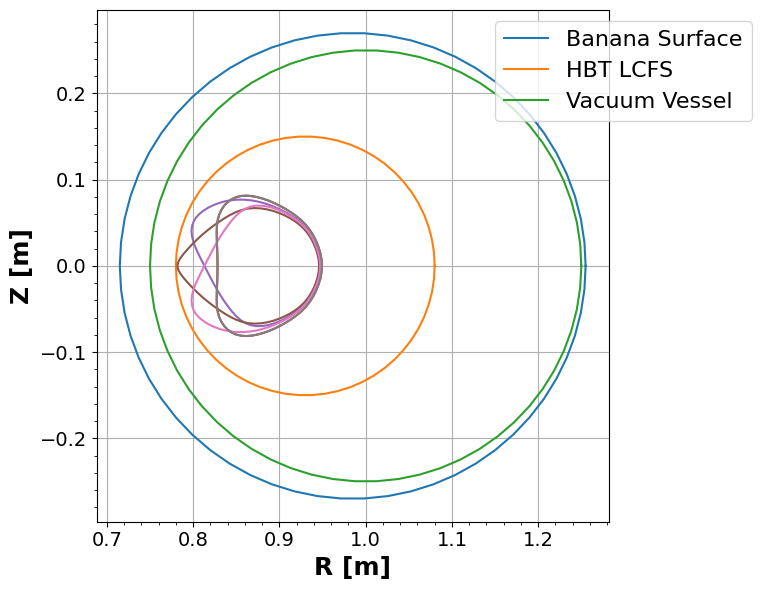

In [114]:
# plots cross section of plasma at a few toroidal locations and relevant HBT cross sections
plt.figure(figsize=(7,6))
cs2 = surf_coils.cross_section(0)
rs2 = np.sqrt(cs2[:,0]**2 + cs2[:,1]**2); rs2 = np.append(rs2, rs2[0])
zs2 = cs2[:,2]; zs2 = np.append(zs2, zs2[0])    
plt.plot(rs2, zs2, label='Banana Surface')
cs3 = hbt.cross_section(0)
rs3 = np.sqrt(cs3[:,0]**2 + cs3[:,1]**2); rs3 = np.append(rs3, rs3[0])
zs3 = cs3[:,2]; zs3 = np.append(zs3, zs3[0])
hbt_poly = Polygon(zip(rs3, zs3))
plt.plot(rs3, zs3, label='HBT LCFS')
cs_vv = VV.cross_section(0)
rs_vv = np.sqrt(cs_vv[:, 0]**2 + cs_vv[:, 1]**2); zs_vv = cs_vv[:, 2]
rs_vv = np.append(rs_vv, rs_vv[0]); zs_vv = np.append(zs_vv, zs_vv[0])
plt.plot(rs_vv, zs_vv, label='Vacuum Vessel')
phi_array = np.linspace(0, 1 / surf_coils.nfp, 5) # scaled from 0 to 1
for phi_slice in phi_array:
    cs = surf.cross_section(phi_slice * 2 * np.pi)
    rs = np.sqrt(cs[:,0]**2 + cs[:,1]**2); rs = np.append(rs, rs[0])
    zs = cs[:,2]; zs = np.append(zs, zs[0])
    plasma_poly = Polygon(zip(rs, zs))
    if plasma_poly.within(hbt_poly):
        print("plasma surface within HBT LCFS")
    else:
        print("plasma surface not within HBT LCFS")
    plt.plot(rs, zs)
plt.xlabel('R [m]', fontsize=18, fontweight='bold')
plt.ylabel('Z [m]', fontsize=18, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.gca().set_aspect('equal', adjustable='box')
plt.minorticks_on()
plt.grid(True)
plt.tight_layout()

In [5]:
# Create the TF coils in HBT - these will be fixed but create background toroidal field:
tf_curves = create_equally_spaced_curves(20, 1, stellsym=False, R0=0.985, R1=0.4, order=1)
tf_currents = [Current(1.0) * 1e5 for i in range(20)]   # At some point, update with actual HBT TF current

# All the TF degrees of freedom are fixed
for tf_curve in tf_curves:
    tf_curve.fix_all()
for tf_current in tf_currents:
    tf_current.fix_all()

tf_coils = [Coil(curve,current) for curve, current in zip(tf_curves,tf_currents)]

# Initialization parameters for banana coil
# Initialize at inboard midplane (theta_center = 0.5) and mirrored over plane of symmetry
theta_center = 0.5
phi_center = 0 #1 / surf_coils.nfp / 2 # coil center should lie over the stellarator symmetric plane
theta_width = 0.1
phi_width = 0.5 * 1 / surf_coils.nfp / 2 
num_quadpoints = 128 # number of quadature points for coils
order = 2 # number of Fourier modes for coils

def initializeCoils():
    # Initialize banana coil
    banana_curve = CurveCWSFourierCPP(np.linspace(0, 1, num_quadpoints), order=order, surf=surf_coils)
    banana_curve.set('phic(0)', phi_center)
    banana_curve.set('thetac(0)', theta_center)
    banana_curve.set('phic(1)', phi_width)
    banana_curve.set('thetas(1)', theta_width)
    # We need these coils to be stellarator symmetric - fix the non-stellarator symmetric dofs
    # This is not working properly yet
    # for dof in banana_curve.dof_names:
    #     if 'phis' in dof or 'thetac' in dof:
    #         print(dof)
    #         banana_curve.fix(dof.split(':')[1])
    
    # Apply symmetries - if stellsym = False, only one per half field period (and two if true)
    banana_coils = coils_via_symmetries([banana_curve], [ScaledCurrent(Current(1), 1e4)], surf_coils.nfp, surf_coils.stellsym)
    
    # Combined coil set to evaluate magnetic field
    coils = tf_coils + banana_coils
    bs = BiotSavart(coils)
    bs.set_points(surf.gamma().reshape((-1, 3)))
    
    # Save initialization state
    curves = [c.curve for c in coils]
    curves_to_vtk(curves, OUT_DIR + "curves_init", close=True)
    pointData = {"B_N": np.sum(bs.B().reshape((nphi, ntheta, 3)) * surf.unitnormal(), axis=2)[:, :, None]}
    surf.to_vtk(OUT_DIR + "surf_init", extra_data=pointData)
    return bs, curves, banana_curve, banana_coils

In [6]:
def magneticFieldPlots(surf, bs, OUT_DIR_ITER):
    # Plot the normal magnetic field on the plasma surface (want this to be much less than 1e-2, ideally around 2e-3 or so)
    theta = surf.quadpoints_theta
    phi = surf.quadpoints_phi
    n = surf.normal()
    absn = np.linalg.norm(n, axis=2)
    unitn = n * (1./absn)[:,:,None]
    sqrt_area = np.sqrt(absn.reshape((-1,1))/float(absn.size))
    surf_area = sqrt_area**2
    bs.set_points(surf.gamma().reshape((-1, 3)))
    Bfinal = bs.B().reshape(n.shape)
    Bfinal_norm = np.sum(Bfinal * unitn, axis=2)[:, :, None]
    modBfinal = np.sqrt(np.sum(Bfinal**2, axis=2))[:, :, None]
    relBfinal_norm = Bfinal_norm / modBfinal
    abs_relBfinal_norm_dA = np.abs(relBfinal_norm.reshape((-1, 1))) * surf_area
    mean_abs_relBfinal_norm = np.sum(abs_relBfinal_norm_dA) / np.sum(surf_area)
    max_rBnorm = np.max(np.abs(relBfinal_norm))
    relBfinal_norm = np.sum(bs.B().reshape((nphi, ntheta, 3)) * surf.unitnormal(), axis=2)[:, :, None] / np.sqrt(np.sum(bs.B().reshape((nphi, ntheta, 3))**2, axis=2))[:, :, None]
    fig, ax = plt.subplots()
    contour = ax.contourf(phi, theta, np.squeeze(relBfinal_norm).T, levels=50, cmap='seismic', vmin=-max_rBnorm, vmax=max_rBnorm)
    ax.set_xlabel(r'$\phi/2\pi$', fontsize=18, fontweight='bold')
    ax.set_ylabel(r'$\theta/2\pi$', fontsize=18, fontweight='bold')
    cbar = fig.colorbar(contour, ax=ax)
    cbar.ax.set_ylabel(r'$\mathbf{B}\cdot\mathbf{n}/|\mathbf{B}|$', fontsize=16, fontweight='bold')
    cbar.ax.tick_params(axis='y', which='major', labelsize=14)
    ax.set_title(f'Surface-averaged \n |Bn|/|B| = {mean_abs_relBfinal_norm:.4e}', fontsize=18, fontweight='bold')
    #plt.tight_layout()
    plt.savefig(OUT_DIR_ITER + "NormFieldPlot.png")

    # Plot magnitude of magnetic field on the plasma surface
    abs_modBfinal_dA = np.abs(modBfinal.reshape((-1, 1))) * surf_area
    mean_abs_modBfinal = np.sum(abs_modBfinal_dA) / np.sum(surf_area)
    fig, ax = plt.subplots()
    contour = ax.contour(phi, theta, np.squeeze(modBfinal).T, levels=25, cmap='viridis')
    ax.set_xlabel(r'$\phi/2\pi$', fontsize=18, fontweight='bold')
    ax.set_ylabel(r'$\theta/2\pi$', fontsize=18, fontweight='bold')
    cbar = fig.colorbar(contour, ax=ax)
    cbar.ax.set_ylabel(r'$|\mathbf{B}|$', fontsize=16, fontweight='bold')
    cbar.ax.tick_params(axis='y', which='major', labelsize=14)
    ax.set_title(f'Surface-averaged |B| = {mean_abs_modBfinal:.3f}', fontsize=18, fontweight='bold')
    #plt.tight_layout()
    plt.savefig(OUT_DIR_ITER + "MagFieldPlot.png")

In [7]:
def crossSectionPlot(surf_coils, surf, banana_curve, OUT_DIR_ITER):
    # Same plot as above but this time also plot the coil cross section in the R-Z plane so we can see the poloidal extent
    # We don't want it to wrap too far around the device
    plt.figure(figsize=(7,6))
    cs2 = surf_coils.cross_section(0)
    rs2 = np.sqrt(cs2[:,0]**2 + cs2[:,1]**2); rs2 = np.append(rs2, rs2[0])
    zs2 = cs2[:,2]; zs2 = np.append(zs2, zs2[0])    
    plt.plot(rs2, zs2, label='Banana Surface')
    cs3 = hbt.cross_section(0)
    rs3 = np.sqrt(cs3[:,0]**2 + cs3[:,1]**2); rs3 = np.append(rs3, rs3[0])
    zs3 = cs3[:,2]; zs3 = np.append(zs3, zs3[0])    
    plt.plot(rs3, zs3, label='HBT LCFS')
    cs_vv = VV.cross_section(0)
    rs_vv = np.sqrt(cs_vv[:, 0]**2 + cs_vv[:, 1]**2); zs_vv = cs_vv[:, 2]
    rs_vv = np.append(rs_vv, rs_vv[0]); zs_vv = np.append(zs_vv, zs_vv[0])
    plt.plot(rs_vv, zs_vv, label='Vacuum Vessel')
    phi_array = np.linspace(0, 0.5 / surf.nfp, 6, endpoint=True) # scaled from 0 to 1
    for phi_slice in phi_array:
        cs = surf.cross_section(phi_slice * 2 * np.pi)
        rs = np.sqrt(cs[:,0]**2 + cs[:,1]**2); rs = np.append(rs, rs[0])
        zs = cs[:,2]; zs = np.append(zs, zs[0])
        plt.plot(rs, zs)
    gamma = banana_curve.gamma()
    rs = np.sqrt(gamma[:,0]**2 + gamma[:,1]**2); rs = np.append(rs, rs[0])
    zs = gamma[:,2]; zs = np.append(zs, zs[0])
    plt.plot(rs, zs, label='Banana Coil', color='black', linewidth=3)
    plt.xlabel('R [m]', fontsize=18, fontweight='bold')
    plt.ylabel('Z [m]', fontsize=18, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.minorticks_on()
    plt.grid(True)
    #plt.tight_layout()
    plt.savefig(OUT_DIR_ITER + "CrossSectionPlot.png")

Initial coil length: 1.48 [m]
J=1.2e-03, Jf=1.2e-03, ⟨B·n⟩=1.4e-02, Len=1.5m, C-C-Sep=0.13m, Curvature=0.00, ║∇J║=1.0e-02
J=5.2e-01, Jf=1.3e-02, ⟨B·n⟩=5.9e-02, Len=30.6m, C-C-Sep=0.00m, Curvature=0.00, ║∇J║=4.8e+01
J=1.2e-03, Jf=1.2e-03, ⟨B·n⟩=1.4e-02, Len=1.5m, C-C-Sep=0.13m, Curvature=0.00, ║∇J║=1.0e-02
J=1.2e-03, Jf=1.2e-03, ⟨B·n⟩=1.4e-02, Len=1.5m, C-C-Sep=0.13m, Curvature=0.00, ║∇J║=1.0e-02
J=1.3e-01, Jf=3.2e-03, ⟨B·n⟩=2.6e-02, Len=12.5m, C-C-Sep=0.00m, Curvature=66.13, ║∇J║=6.1e+00
J=4.6e-02, Jf=1.5e-03, ⟨B·n⟩=1.6e-02, Len=3.3m, C-C-Sep=0.13m, Curvature=448.92, ║∇J║=3.3e+01
J=9.9e-04, Jf=9.9e-04, ⟨B·n⟩=1.3e-02, Len=1.6m, C-C-Sep=0.13m, Curvature=0.00, ║∇J║=6.9e-03
J=3.8e-03, Jf=9.1e-04, ⟨B·n⟩=1.2e-02, Len=1.6m, C-C-Sep=0.13m, Curvature=28.54, ║∇J║=2.7e+00
J=9.7e-04, Jf=9.7e-04, ⟨B·n⟩=1.3e-02, Len=1.6m, C-C-Sep=0.13m, Curvature=0.00, ║∇J║=6.5e-03
J=1.6e-03, Jf=9.2e-04, ⟨B·n⟩=1.2e-02, Len=1.6m, C-C-Sep=0.13m, Curvature=6.63, ║∇J║=1.1e+00
J=9.6e-04, Jf=9.6e-04, ⟨B·n⟩=1.2e-02, Len=1.

KeyboardInterrupt: 

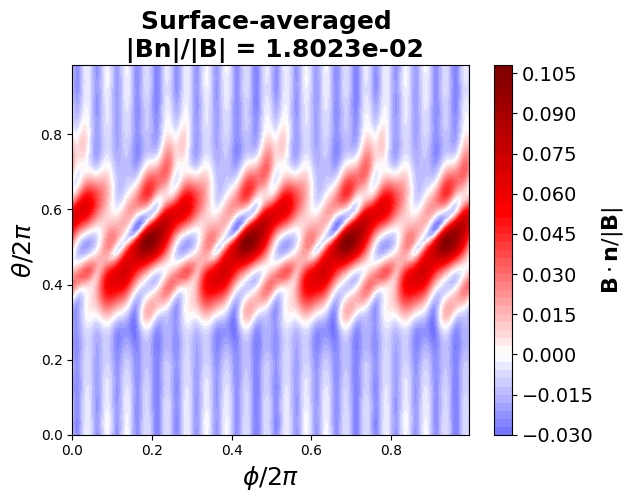

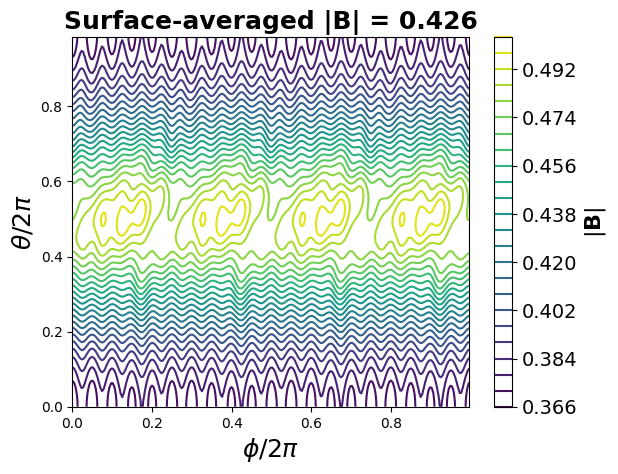

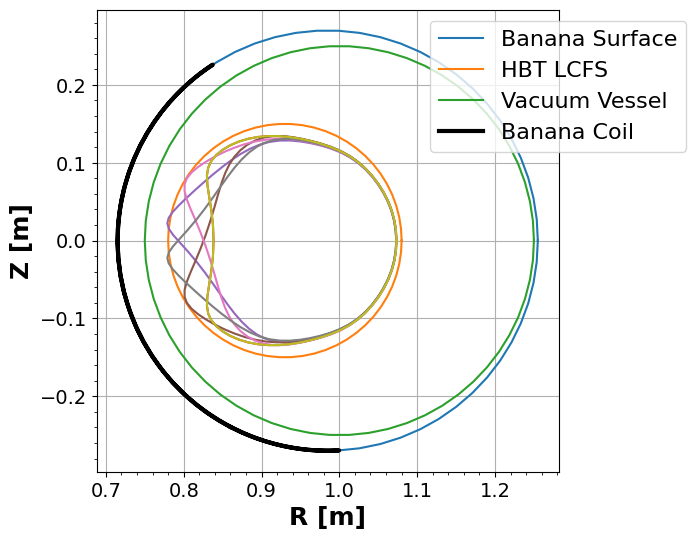

In [8]:
def fun(dofs):
    JF.x = dofs
    J = JF.J()
    grad = JF.dJ()
    BdotN = np.mean(np.abs(np.sum(new_bs.B().reshape((nphi, ntheta, 3)) * new_surf.unitnormal(), axis=2)))
    outstr = f"J={J:.1e}, Jf={Jf.J():.1e}, ⟨B·n⟩={BdotN:.1e}"
    outstr += f", Len={Jls.J():.1f}m"
    outstr += f", C-C-Sep={Jccdist.shortest_distance():.2f}m"
    outstr += f", Curvature={Jc.J():.2f}"
    outstr += f", ║∇J║={np.linalg.norm(grad):.1e}"
    print(outstr)
    return J, grad

for i in range(1, 11):
    init_coil_array = initializeCoils()
    
    # Number of iterations to perform:
    MAXITER = 300
    
    new_surf = surf
    new_bs = init_coil_array[0]
    new_curves = init_coil_array[1]
    new_banana_curve = init_coil_array[2]
    new_banana_coils = init_coil_array[3]
    new_tf_coils = tf_coils
    new_surf_coils = surf_coils
    
    # Define the individual terms objective function:
    Jf = SquaredFlux(new_surf, new_bs)
    Jls = CurveLength(new_banana_curve)
    
    # Weight on the curve lengths in the objective function
    # We'll penalize the coil if it becomes longer than it was initialized to
    LENGTH_WEIGHT = i * 1e-6
    LENGTH_TARGET = Jls.J() # initial length
    
    print(f"Initial coil length: {Jls.J():.2f} [m]")
    
    # Threshold and weight for the coil-to-coil distance penalty
    CC_THRESHOLD = 0.05 # keep 5 cm between coils (arbitrary)
    CC_WEIGHT = 100
    
    # Threshold and weight for the coil curvature penalty
    CURVATURE_WEIGHT = 1e-4
    CURVATURE_THRESHOLD = 40 * 1/(LENGTH_TARGET/(2*np.pi)) # (arbitrary)
    
    Jccdist = CurveCurveDistance(new_curves, CC_THRESHOLD)
    Jc = LpCurveCurvature(new_banana_curve, 2, CURVATURE_THRESHOLD)
    
    # Total objective function - 
    # we'll penalize the coil length, coil-coil distance, and curvature while minimizing the normal field
    JF = Jf \
        + LENGTH_WEIGHT * QuadraticPenalty(Jls, LENGTH_TARGET, "max") \
        + CC_WEIGHT * Jccdist \
        + CURVATURE_WEIGHT * Jc
    
    # iterating through simulations of 10 increasing length weights
    # for i in range(1, 11):
    # LENGTH_WEIGHT = i * 1e-6
    
    dofs = JF.x
    res = minimize(fun, dofs, jac=True, method='L-BFGS-B', options={'maxiter': MAXITER, 'maxcor': 300}, tol=1e-15)
    print(res.message)
    
    OUT_DIR_ITER = f"{OUT_DIR}LW={LENGTH_WEIGHT}-CCW={CC_WEIGHT}-CW={CURVATURE_WEIGHT}-SR={banana_surf_radius:0.2f}-Order={order}/"
    os.makedirs(OUT_DIR_ITER, exist_ok=True)
    
    curves_to_vtk(new_curves, OUT_DIR_ITER + "curves_opt", close=True)
    pointData = {"B_N/B": np.sum(new_bs.B().reshape((nphi, ntheta, 3)) * new_surf.unitnormal(), axis=2)[:, :, None] / np.sqrt(np.sum(new_bs.B().reshape((nphi, ntheta, 3))**2, axis=2))[:, :, None]}
    new_surf.to_vtk(OUT_DIR_ITER + "surf_opt", extra_data=pointData)
    new_surf_coils.to_vtk(OUT_DIR_ITER + "VV")

    # Create plots
    magneticFieldPlots(new_surf, new_bs, OUT_DIR_ITER)
    crossSectionPlot(new_surf_coils, new_surf, new_banana_curve, OUT_DIR_ITER)
    
    # Save the optimized coil shapes and currents so they can be loaded into other scripts for analysis:
    new_bs.save(OUT_DIR_ITER + "biot_savart_opt.json");
    print(f'Banana Coil Current / TF Current = {new_banana_coils[0].current.get_value() / new_tf_coils[0].current.get_value():.3f}\n')


In [36]:
# Print out the values of the degrees of freedom
for dof_name in banana_curve.dof_names:
    print(dof_name, banana_curve.get(dof_name.split(':')[1]))

CurveCWSFourierCPP16:phic(0) 0.160490974113343
CurveCWSFourierCPP16:phic(1) 0.011212434670055133
CurveCWSFourierCPP16:phic(2) 0.05408996530760489
CurveCWSFourierCPP16:phis(1) 0.19410619432043338
CurveCWSFourierCPP16:phis(2) 0.005587828325452735
CurveCWSFourierCPP16:thetac(0) 0.6077023605512066
CurveCWSFourierCPP16:thetac(1) -0.003970945401201624
CurveCWSFourierCPP16:thetac(2) 0.039847112440594246
CurveCWSFourierCPP16:thetas(1) 0.2195547914154353
CurveCWSFourierCPP16:thetas(2) 0.025949039867861408
